In [2]:
import pandas as pd

listings = pd.read_parquet("../data/interim/listings_final2_silver.parquet")
calendar = pd.read_parquet("../data/interim/calendar_silver.parquet")
reviews = pd.read_parquet("../data/interim/reviews_silver.parquet")
neighbourhoods = pd.read_parquet("../data/interim/neighbourhoods_silver.parquet")

print(listings.shape, calendar.shape, reviews.shape, neighbourhoods.shape)

(30259, 95) (11152576, 5) (990170, 6) (230, 2)


##4.1 — Summary Statistics & Distributions

#Descriptive statistics for key numerical variables

In [3]:
key_numeric_cols = [
    'price', 'accommodates', 'bedrooms', 'bathrooms', 'minimum_nights',
    'availability_365', 'number_of_reviews', 'review_scores_rating',
    'occupancy_rate', 'estimated_revenue', 'price_per_bedroom'
]

listings[key_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,21515.0,278.229518,531.730477,4.58,96.8750,174.6900,302.720,30972.96
accommodates,30259.0,2.862785,1.979306,1.00,2.0000,2.0000,4.000,16.00
bedrooms,19286.0,1.573473,0.918719,0.00,1.0000,1.0000,2.000,19.00
bathrooms,20147.0,1.212612,0.541856,0.50,1.0000,1.0000,1.000,15.50
minimum_nights,30257.0,26.893611,27.476898,1.00,30.0000,30.0000,30.000,1124.00
availability_365,30259.0,185.838131,139.363606,0.00,27.0000,207.0000,318.000,365.00
number_of_reviews,30259.0,32.405301,79.078916,0.00,0.0000,4.0000,29.000,4502.00
review_scores_rating,21700.0,4.732956,0.447274,0.00,4.6700,4.8600,5.000,5.00
occupancy_rate,30259.0,0.490811,0.381809,0.00,0.1288,0.4329,0.926,1.00
estimated_revenue,21515.0,29980.607112,68478.403314,0.00,3861.5000,14565.3200,34850.400,3462697.74


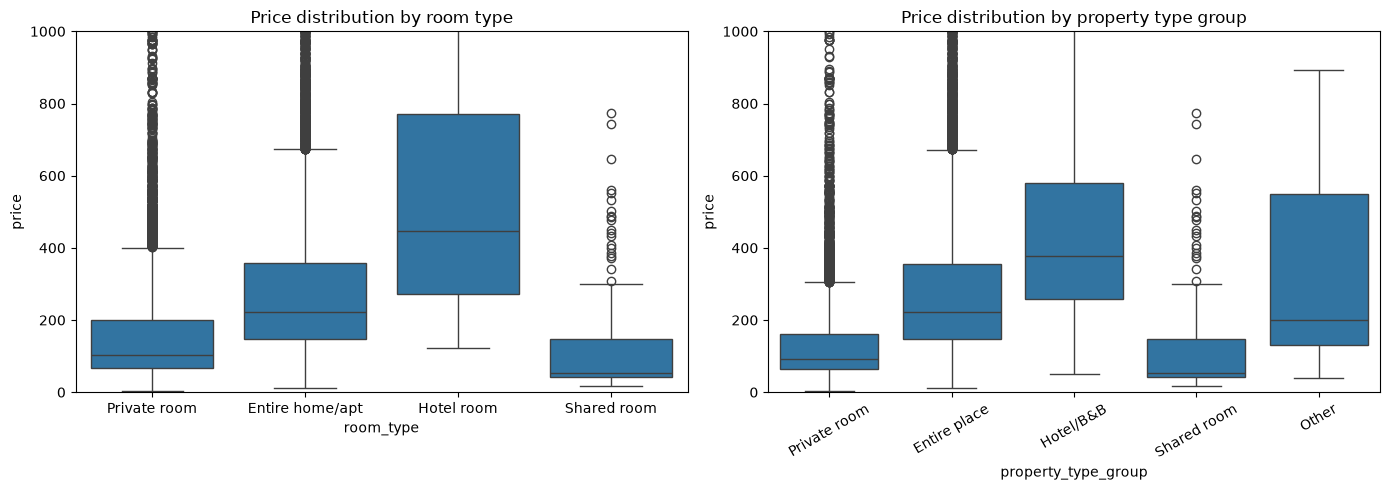

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=listings, x='room_type', y='price', ax=axes[0])
axes[0].set_title('Price distribution by room type')
axes[0].set_ylim(0, 1000)  # cap for readability given known outliers

sns.boxplot(data=listings, x='property_type_group', y='price', ax=axes[1])
axes[1].set_title('Price distribution by property type group')
axes[1].set_ylim(0, 1000)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()

import os
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/fig01_price_by_type.png", dpi=150, bbox_inches='tight')

plt.show()

 #Listing counts per host (power law check)

count    16474.000000
mean         1.836773
std          9.964150
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        955.000000
dtype: float64

Top 10 hosts by listing count:
host_id
107434423    955
446820235    331
51501835     262
19303369     239
162280872    231
35491667     217
476218709    214
200239515    212
204704622    205
137358866    157
dtype: int64


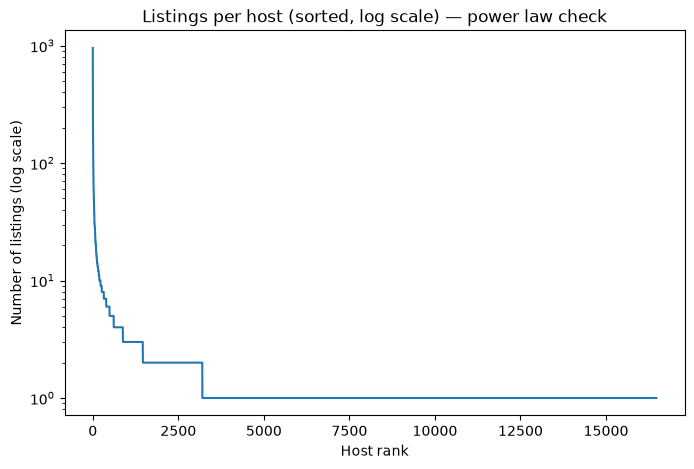

In [5]:
host_listing_counts = listings.groupby('host_id').size().sort_values(ascending=False)
print(host_listing_counts.describe())
print(f"\nTop 10 hosts by listing count:\n{host_listing_counts.head(10)}")

# Power law visual
plt.figure(figsize=(8,5))
host_listing_counts.reset_index(drop=True).plot(logy=True)
plt.title("Listings per host (sorted, log scale) — power law check")
plt.xlabel("Host rank")
plt.ylabel("Number of listings (log scale)")

import os

plt.savefig("../reports/figures/fig02_host_power_law.png", dpi=150, bbox_inches='tight')

plt.show()

#Review score distribution + rating inflation check

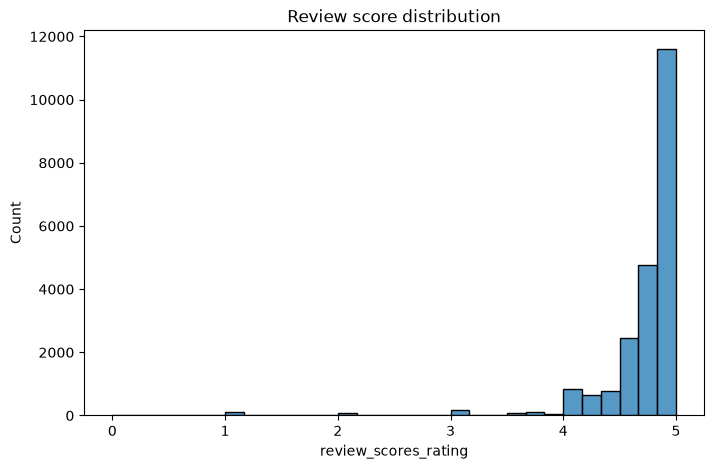

count    21700.000000
mean         4.732956
std          0.447274
min          0.000000
25%          4.670000
50%          4.860000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

% of rated listings scoring 4.8 or above: 43.2%


In [6]:
plt.figure(figsize=(8,5))
sns.histplot(listings['review_scores_rating'].dropna(), bins=30)
plt.title("Review score distribution")

import os

plt.savefig("../reports/figures/fig03_review_score_dist.png", dpi=150, bbox_inches='tight')

plt.show()

print(listings['review_scores_rating'].describe())
print(f"\n% of rated listings scoring 4.8 or above: {(listings['review_scores_rating'] >= 4.8).mean()*100:.1f}%")

#Availability patterns

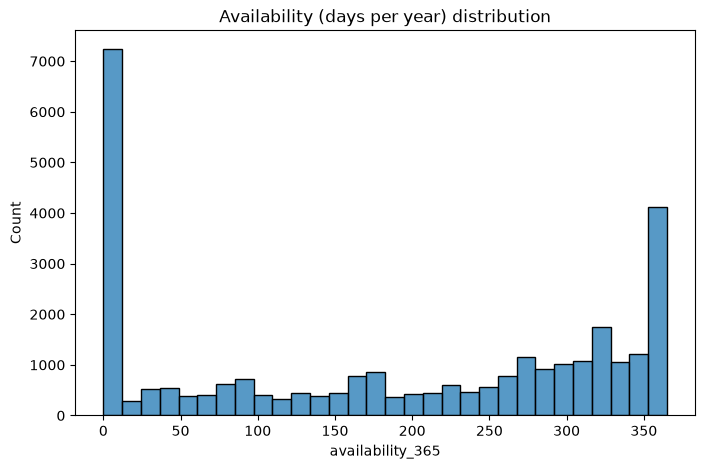

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(listings['availability_365'].dropna(), bins=30)
plt.title("Availability (days per year) distribution")

import os

plt.savefig("../reports/figures/fig04_availability_dist.png", dpi=150, bbox_inches='tight')

plt.show()

In [7]:
# Do highly-available listings belong to high-volume hosts?
listings['host_scale'] = listings['host_id'].map(host_listing_counts)
print(listings.groupby(pd.cut(listings['availability_365'], bins=[0,10,100,250,365]))['host_scale'].mean())

availability_365
(0, 10]       277.463700
(10, 100]      59.188632
(100, 250]     49.021203
(250, 365]     69.338420
Name: host_scale, dtype: float64


#Geographic & Spa al Analysis

In [18]:
neighbourhood_price = listings.groupby(['neighbourhood_group_cleansed', 'neighbourhood_cleansed']).agg(
    median_price=('price', 'median'),
    listing_count=('id', 'count'),
    avg_rating=('review_scores_rating', 'mean')
).reset_index()

# Top 15 by listing count for a readable chart
top15 = neighbourhood_price.nlargest(15, 'listing_count')
print(top15)

    neighbourhood_group_cleansed neighbourhood_cleansed  median_price  \
51                      Brooklyn     Bedford-Stuyvesant       133.775   
114                    Manhattan                Midtown       378.720   
95                      Brooklyn           Williamsburg       187.610   
107                    Manhattan                 Harlem       117.840   
108                    Manhattan         Hell's Kitchen       234.170   
126                    Manhattan        Upper West Side       206.500   
125                    Manhattan        Upper East Side       229.790   
59                      Brooklyn               Bushwick       112.740   
66                      Brooklyn          Crown Heights       148.080   
98                     Manhattan                Chelsea       238.820   
102                    Manhattan           East Village       213.180   
103                    Manhattan     Financial District       407.000   
101                    Manhattan            East Ha

#Listing density map + price gradient (lat/long scatter)

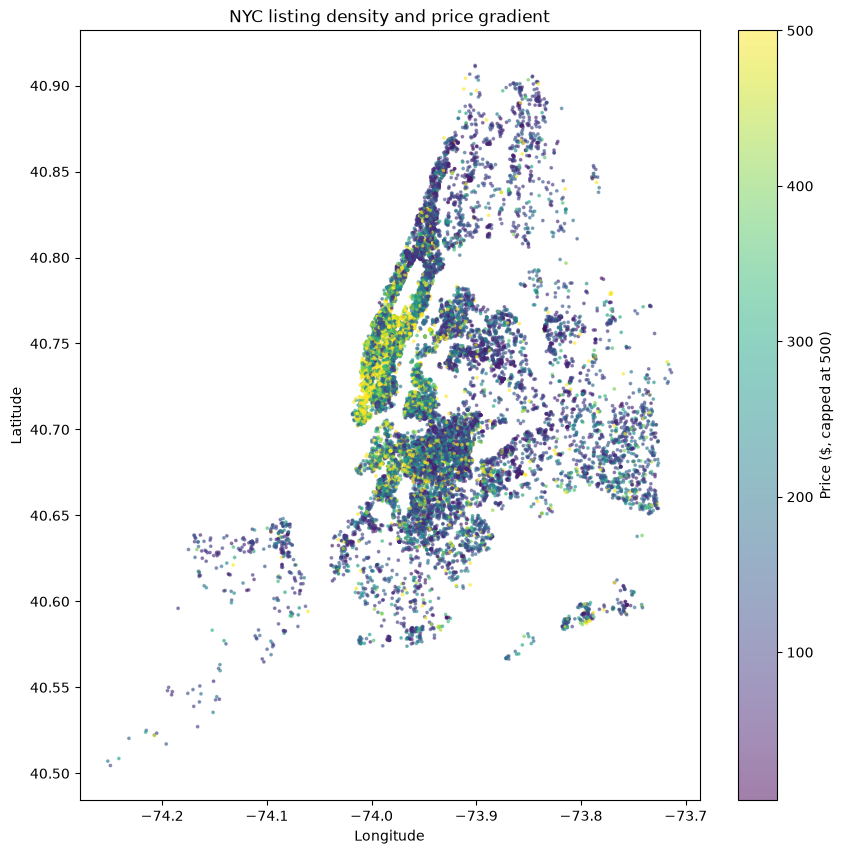

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    listings['longitude'], listings['latitude'],
    c=listings['price'].clip(upper=500),  # cap for color scale readability
    cmap='viridis', s=3, alpha=0.5
)
plt.colorbar(scatter, label='Price ($, capped at 500)')
ax.set_title('NYC listing density and price gradient')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

import os

plt.savefig("../reports/figures/fig05_price_map.png", dpi=150, bbox_inches='tight')

plt.show()

#Price vs. distance from city center (quantified)

Correlation between distance from center and price: -0.178


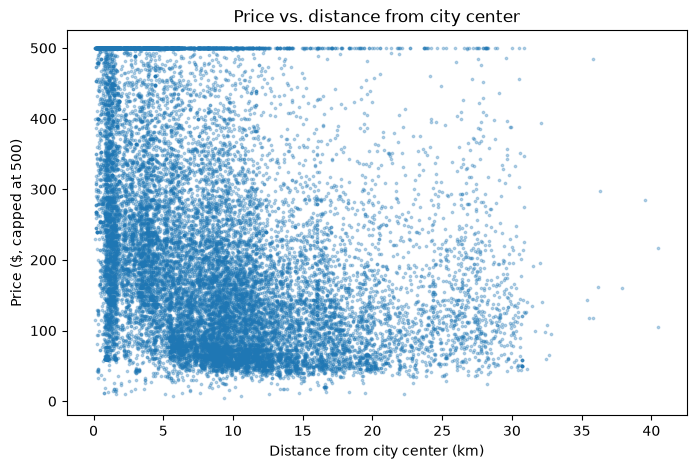

In [9]:
import numpy as np

center_lat, center_lon = 40.7549, -73.9840

listings['dist_from_center_km'] = np.sqrt(
    (listings['latitude'] - center_lat)**2 + (listings['longitude'] - center_lon)**2
) * 111  # rough degrees-to-km conversion

correlation = listings[['dist_from_center_km', 'price']].corr().iloc[0,1]
print(f"Correlation between distance from center and price: {correlation:.3f}")

plt.figure(figsize=(8,5))
plt.scatter(listings['dist_from_center_km'], listings['price'].clip(upper=500), s=3, alpha=0.3)
plt.xlabel('Distance from city center (km)')
plt.ylabel('Price ($, capped at 500)')
plt.title('Price vs. distance from city center')

import os

plt.savefig("../reports/figures/fig06_price_vs_distance.png", dpi=150, bbox_inches='tight')

plt.show()

#Review scores mapped spatially

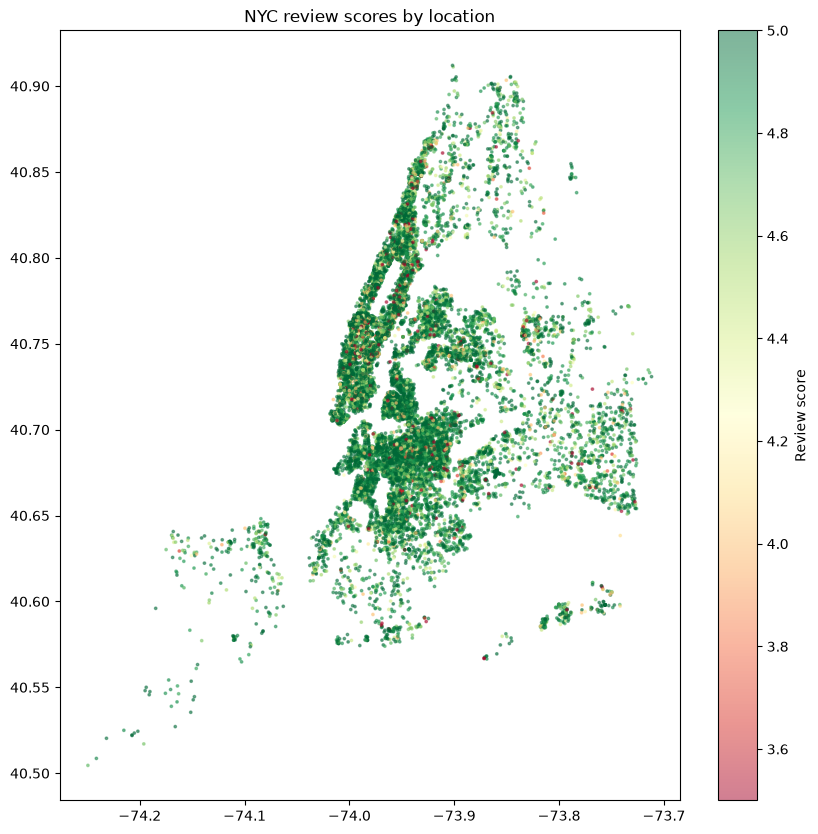

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    listings['longitude'], listings['latitude'],
    c=listings['review_scores_rating'],
    cmap='RdYlGn', s=3, alpha=0.5, vmin=3.5, vmax=5.0
)
plt.colorbar(scatter, label='Review score')
ax.set_title('NYC review scores by location')

import os

plt.savefig("../reports/figures/fig07_reviews_map.png", dpi=150, bbox_inches='tight')

plt.show()

#Geographic clustering of property/room types

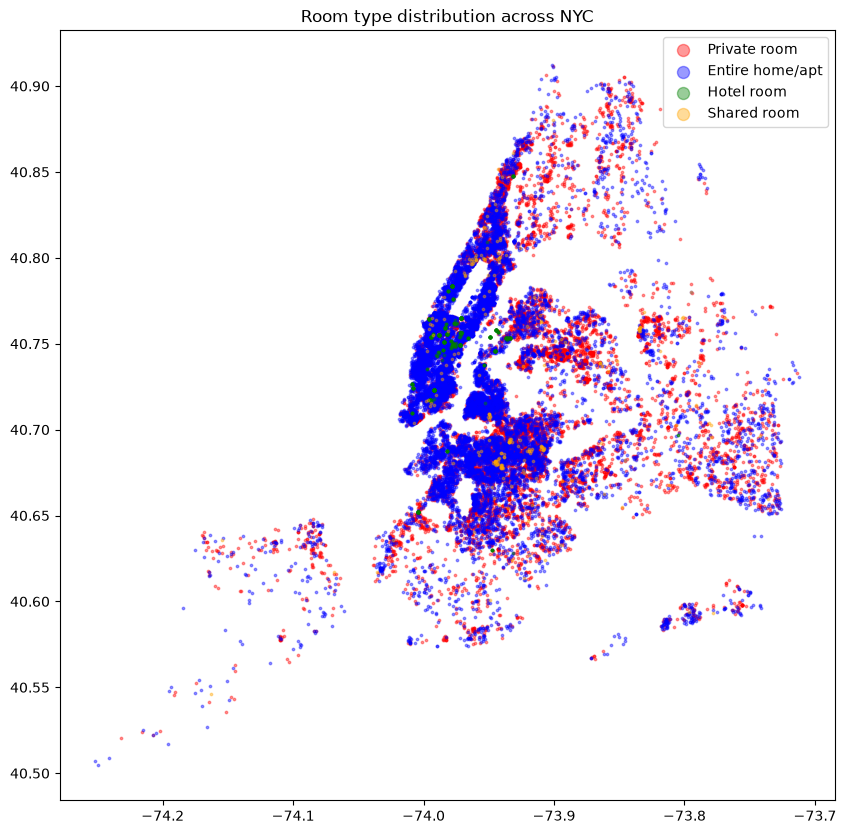

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
for rtype, color in zip(listings['room_type'].unique(), ['red','blue','green','orange']):
    subset = listings[listings['room_type'] == rtype]
    ax.scatter(subset['longitude'], subset['latitude'], s=3, alpha=0.4, label=rtype, color=color)
ax.legend(markerscale=5)
ax.set_title('Room type distribution across NYC')

import os

plt.savefig("../reports/figures/fig08_roomtype_map.png", dpi=150, bbox_inches='tight')

plt.show()

##4.3  Temporal & Seasonal Trends

#Pricing evolution across the calendar year (seasonality)

In [19]:
print(calendar.columns.tolist())

['listing_id', 'date', 'available', 'minimum_nights', 'maximum_nights', 'month']


#Review volume trend over time (bookings growing/declining)

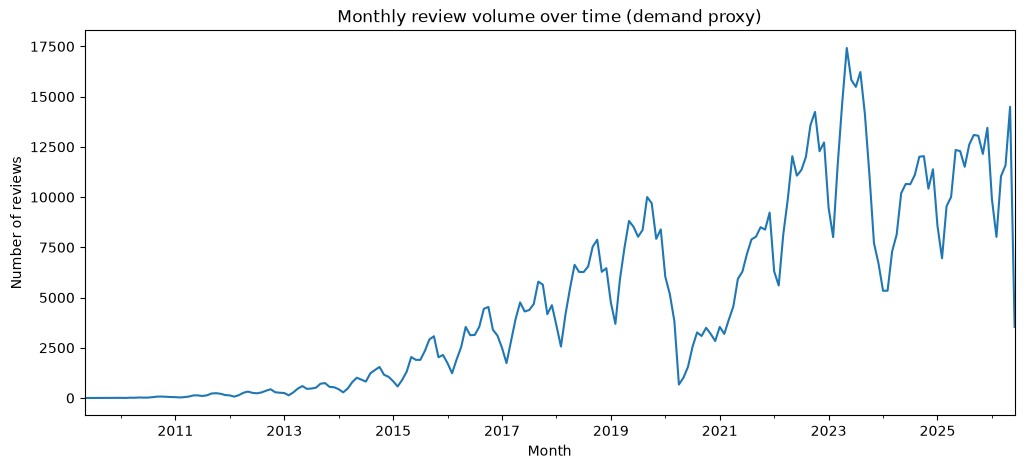

year_month
2025-04    10007
2025-05    12345
2025-06    12288
2025-07    11509
2025-08    12613
2025-09    13092
2025-10    13053
2025-11    12148
2025-12    13449
2026-01     9896
2026-02     8020
2026-03    11040
2026-04    11585
2026-05    14492
2026-06     3539
Freq: M, dtype: int64


In [12]:
import matplotlib.pyplot as plt

reviews['year_month'] = reviews['date'].dt.to_period('M')
monthly_reviews = reviews.groupby('year_month').size()

plt.figure(figsize=(12,5))
monthly_reviews.plot()
plt.title('Monthly review volume over time (demand proxy)')
plt.ylabel('Number of reviews')
plt.xlabel('Month')

import os

plt.savefig("../reports/figures/fig09_review_volume_trend.png", dpi=150, bbox_inches='tight')

plt.show()

print(monthly_reviews.tail(15))

#Host tenure vs. pricing (are newer hosts priced differently?)

In [15]:
tenure_price = listings.groupby(pd.cut(listings['host_tenure_years_est'], bins=[0,2,5,10,20]))['price'].agg(['median','mean','count'])
print(tenure_price)

                        median        mean  count
host_tenure_years_est                            
(0, 2]                 199.230  295.387597   3258
(2, 5]                 173.535  279.980880   7148
(5, 10]                154.870  218.163547   5334
(10, 20]               168.480  231.722354   2009


#Minimum night policy shifts across seasons

month
1     30.0
2     30.0
3     30.0
4     30.0
5     30.0
6     30.0
7     30.0
8     30.0
9     30.0
10    30.0
11    30.0
12    30.0
Name: minimum_nights, dtype: float64


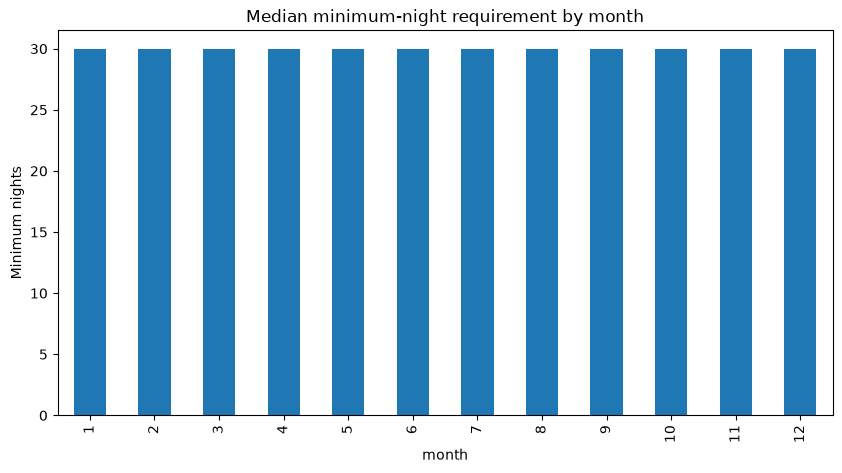

In [16]:
calendar['month'] = calendar['date'].dt.month

seasonal_min_nights = calendar.groupby('month')['minimum_nights'].median()
print(seasonal_min_nights)

plt.figure(figsize=(10,5))
seasonal_min_nights.plot(kind='bar')
plt.title('Median minimum-night requirement by month')
plt.ylabel('Minimum nights')
plt.show()

##4.4  Host & Supply-Side Analysis

#Segment hosts by portfolio size

In [21]:
host_listing_counts = listings.groupby('host_id').size()
listings['host_scale'] = listings['host_id'].map(host_listing_counts)

In [22]:
def host_segment(n):
    if n == 1:
        return 'Single listing'
    elif n <= 5:
        return 'Small (2-5)'
    elif n <= 20:
        return 'Medium (6-20)'
    else:
        return 'Large/commercial (20+)'

listings['host_segment'] = listings['host_scale'].apply(host_segment)

segment_summary = listings.groupby('host_segment').agg(
    num_listings=('id', 'count'),
    num_unique_hosts=('host_id', 'nunique'),
    median_price=('price', 'median'),
    avg_occupancy=('occupancy_rate', 'mean'),
    avg_rating=('review_scores_rating', 'mean')
)
print(segment_summary)

                        num_listings  num_unique_hosts  median_price  \
host_segment                                                           
Large/commercial (20+)          6342                84       220.000   
Medium (6-20)                   3739               405       187.500   
Single listing                 13274             13274       173.355   
Small (2-5)                     6904              2711       146.860   

                        avg_occupancy  avg_rating  
host_segment                                       
Large/commercial (20+)       0.385920    4.555735  
Medium (6-20)                0.351704    4.636888  
Single listing               0.609105    4.803112  
Small (2-5)                  0.435062    4.747221  


#Compare pricing strategies: professional vs. casual hosts

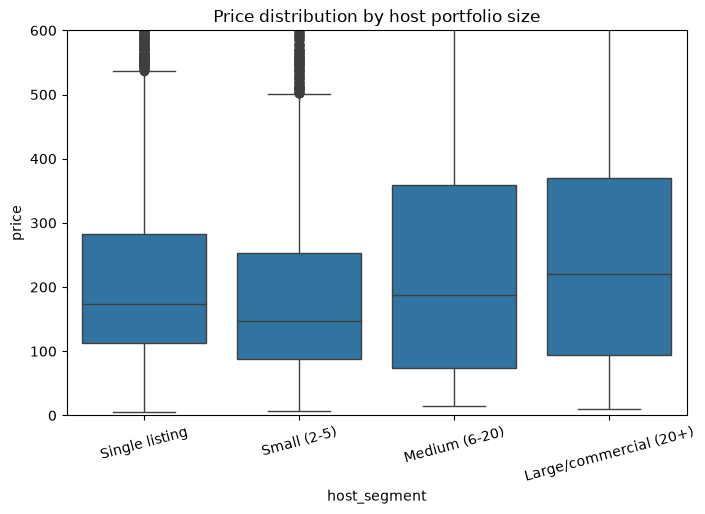

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=listings, x='host_segment', y='price',
            order=['Single listing', 'Small (2-5)', 'Medium (6-20)', 'Large/commercial (20+)'])
plt.ylim(0, 600)
plt.title('Price distribution by host portfolio size')
plt.xticks(rotation=15)

import os

plt.savefig("../reports/figures/fig10_price_by_hostsize.png", dpi=150, bbox_inches='tight')

plt.show()

#Superhost status and response rate vs. performance

In [21]:
superhost_summary = listings.groupby('host_is_superhost').agg(
    num_listings=('id', 'count'),
    median_price=('price', 'median'),
    avg_occupancy=('occupancy_rate', 'mean'),
    avg_rating=('review_scores_rating', 'mean'),
    avg_review_count=('review_count_actual', 'mean')
)
print(superhost_summary)

                   num_listings  median_price  avg_occupancy  avg_rating  \
host_is_superhost                                                          
f                         22814       173.125       0.511951    4.686727   
t                          7096       171.870       0.428819    4.858304   

                   avg_review_count  
host_is_superhost                    
f                         34.872148  
t                         72.278602  


#Market concentration (what % of hosts control majority of listings)

In [22]:
host_counts_sorted = listings.groupby('host_id').size().sort_values(ascending=False)
total_listings = host_counts_sorted.sum()
total_hosts = len(host_counts_sorted)

cumulative_pct = (host_counts_sorted.cumsum() / total_listings * 100)

# What % of hosts control 50% of listings?
hosts_for_50pct = (cumulative_pct <= 50).sum()
print(f"Total hosts: {total_hosts:,}")
print(f"Hosts needed to reach 50% of all listings: {hosts_for_50pct} ({hosts_for_50pct/total_hosts*100:.2f}% of hosts)")

# Top 1% of hosts control what %?
top1pct_n = int(total_hosts * 0.01)
top1pct_share = host_counts_sorted.head(top1pct_n).sum() / total_listings * 100
print(f"Top 1% of hosts ({top1pct_n} hosts) control {top1pct_share:.1f}% of all listings")

Total hosts: 16,474
Hosts needed to reach 50% of all listings: 2272 (13.79% of hosts)
Top 1% of hosts (164 hosts) control 25.0% of all listings


#4.5  Review & Demand-Side Analysis 

#Relationship between review count, review score, and price

                      review_count_actual  review_scores_rating     price
review_count_actual              1.000000              0.055281  0.002879
review_scores_rating             0.055281              1.000000  0.041456
price                            0.002879              0.041456  1.000000


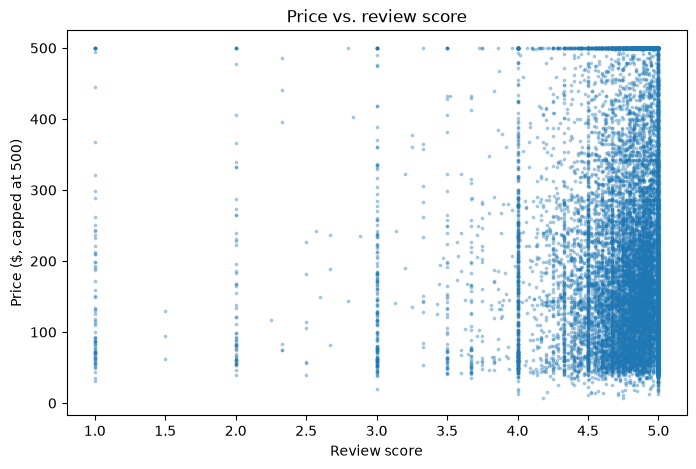

In [23]:
print(listings[['review_count_actual', 'review_scores_rating', 'price']].corr())

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(listings['review_scores_rating'], listings['price'].clip(upper=500), s=3, alpha=0.3)
plt.xlabel('Review score')
plt.ylabel('Price ($, capped at 500)')
plt.title('Price vs. review score')
plt.show()

#Review frequency as a demand proxy

In [24]:
demand_by_room = listings.groupby('room_type')['review_frequency_per_month'].median().sort_values(ascending=False)
print(demand_by_room)

demand_by_neighbourhood = listings.groupby('neighbourhood_group_cleansed')['review_frequency_per_month'].median().sort_values(ascending=False)
print(demand_by_neighbourhood)

room_type
Shared room        1.949
Private room       1.135
Hotel room         0.750
Entire home/apt    0.677
Name: review_frequency_per_month, dtype: float64
neighbourhood_group_cleansed
Queens           1.114
Bronx            1.000
Staten Island    1.000
Brooklyn         0.988
Manhattan        0.667
Name: review_frequency_per_month, dtype: float64


#High review count, low score listings

In [25]:
high_rev_low_score = listings[
    (listings['review_count_actual'] >= 50) &
    (listings['review_scores_rating'] < 4.0)
]

print(f"Listings with 50+ reviews but rating < 4.0: {len(high_rev_low_score)}")
print(high_rev_low_score[['room_type', 'property_type_group', 'host_segment', 'price']].describe(include='all'))
print()
print(high_rev_low_score['neighbourhood_group_cleansed'].value_counts())

Listings with 50+ reviews but rating < 4.0: 3
           room_type property_type_group host_segment       price
count              3                   3            3    3.000000
unique             1                   1            2         NaN
top     Private room           Hotel/B&B  Small (2-5)         NaN
freq               3                   3            2         NaN
mean             NaN                 NaN          NaN  220.220000
std              NaN                 NaN          NaN   96.424874
min              NaN                 NaN          NaN  109.000000
25%              NaN                 NaN          NaN  190.160000
50%              NaN                 NaN          NaN  271.320000
75%              NaN                 NaN          NaN  275.830000
max              NaN                 NaN          NaN  280.340000

neighbourhood_group_cleansed
Manhattan    2
Brooklyn     1
Name: count, dtype: int64


#Review sub-dimensions

In [26]:
sub_score_cols = [c for c in listings.columns if 'review_scores_' in c]
print(sub_score_cols)

['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']


In [27]:
listings[sub_score_cols].corr()

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
review_scores_rating,1.000000,0.819271,0.744805,0.694420,0.771491,0.596551,0.826681
review_scores_accuracy,0.819271,1.000000,0.710979,0.684866,0.714601,0.570678,0.782823
review_scores_cleanliness,0.744805,0.710979,1.000000,0.586586,0.596326,0.496488,0.681109
review_scores_checkin,0.694420,0.684866,0.586586,1.000000,0.698835,0.517967,0.626977
review_scores_communication,0.771491,0.714601,0.596326,0.698835,1.000000,0.514608,0.710910
review_scores_location,0.596551,0.570678,0.496488,0.517967,0.514608,1.000000,0.575674
review_scores_value,0.826681,0.782823,0.681109,0.626977,0.710910,0.575674,1.000000
